In [1]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [2]:
!uv pip install --upgrade seaborn matplotlib

Using Python 3.12.7 environment at: C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv
Resolved 14 packages in 161ms
Audited 14 packages in 2ms


In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)
df = catalog.load("domy_fill_missing_values")

[03/13/26 11:23:49] INFO     Loading data from domy_fill_missing_values (CSVDataset)...        ]8;id=221795;file://C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=794173;file://C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

In [12]:
cat_features_s = []
cat_features_b = []
num_features = []

for col in df.columns:
    if (df[col].dtype == 'object' and df[col].nunique() < 10):
        cat_features_s.append(col)
    elif df[col].dtype == 'object' and df[col].nunique() >= 10:
        cat_features_b.append(col)
    else:
        num_features.append(col)

df_cat_s = df[cat_features_s]
df_cat_b = df[cat_features_b]
df_num = df[num_features]


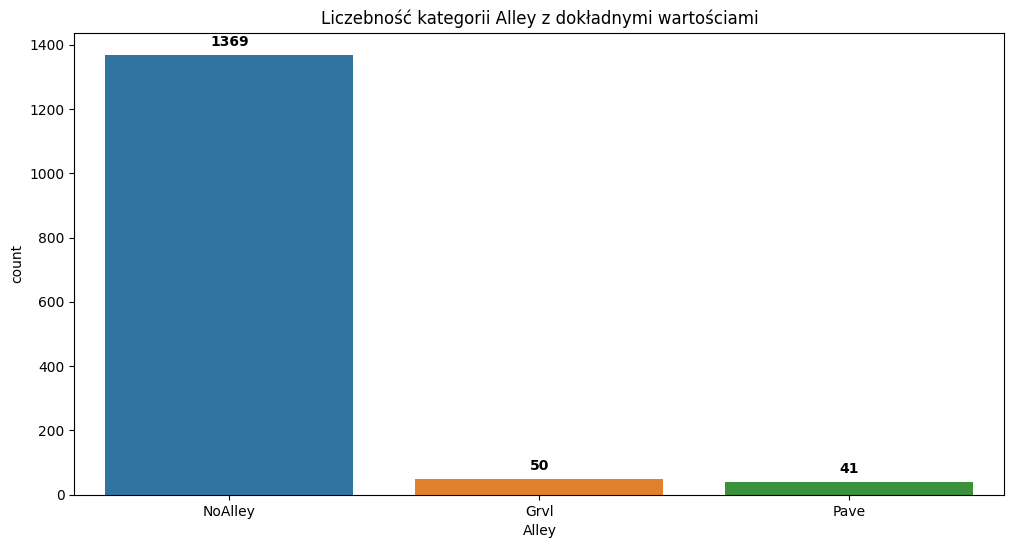

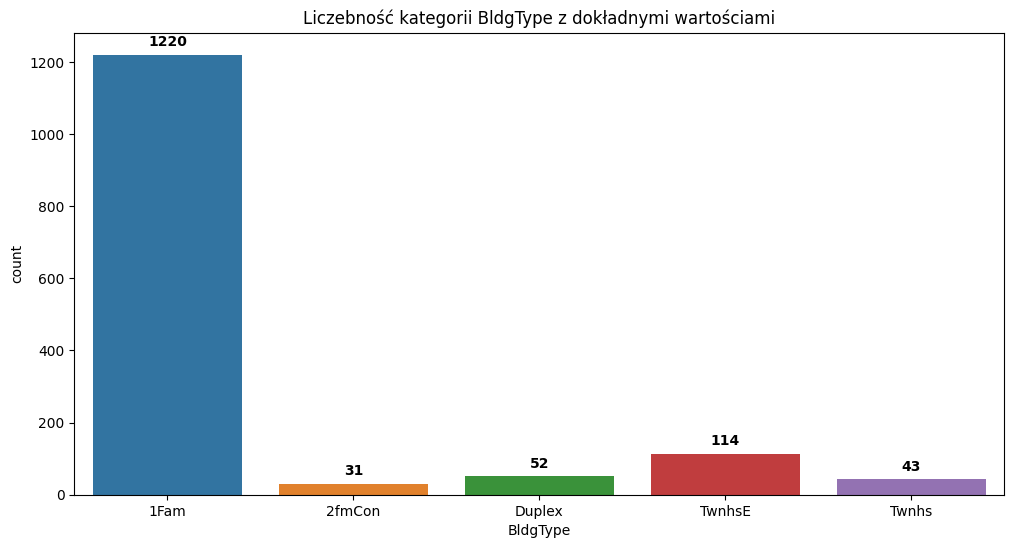

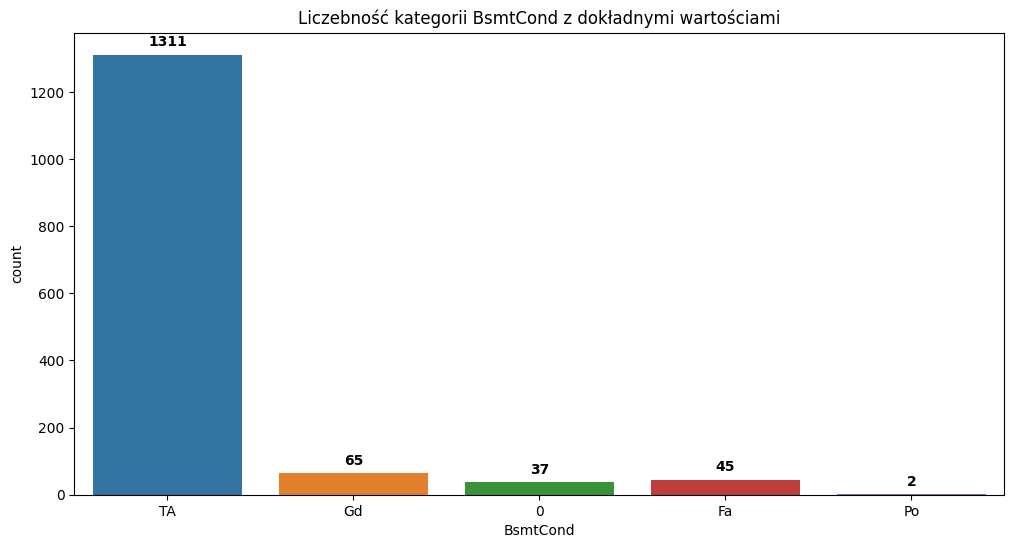

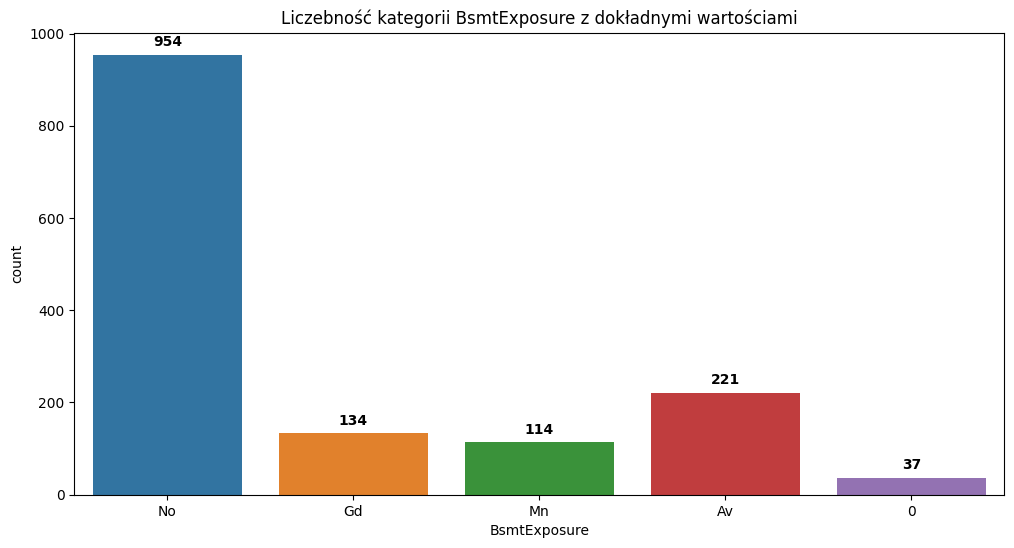

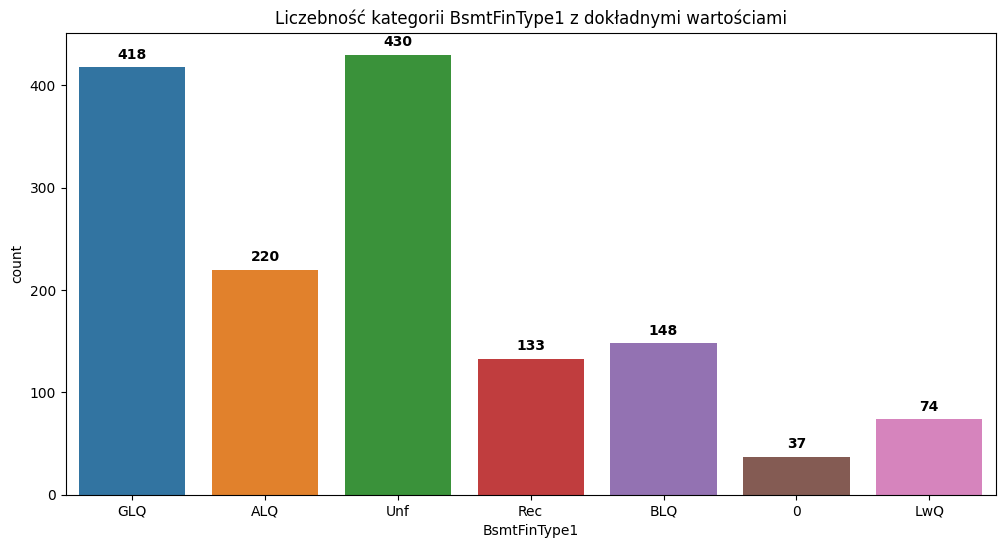

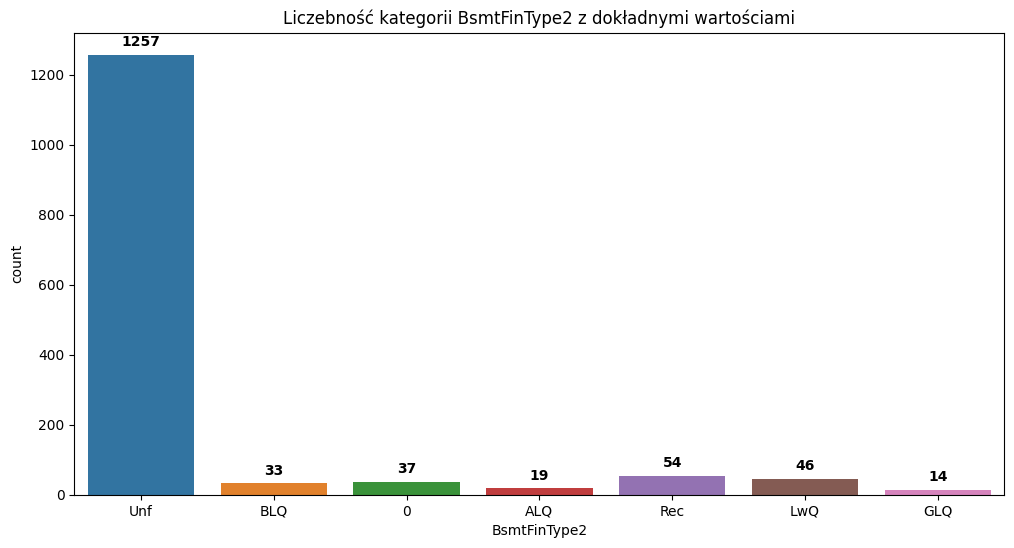

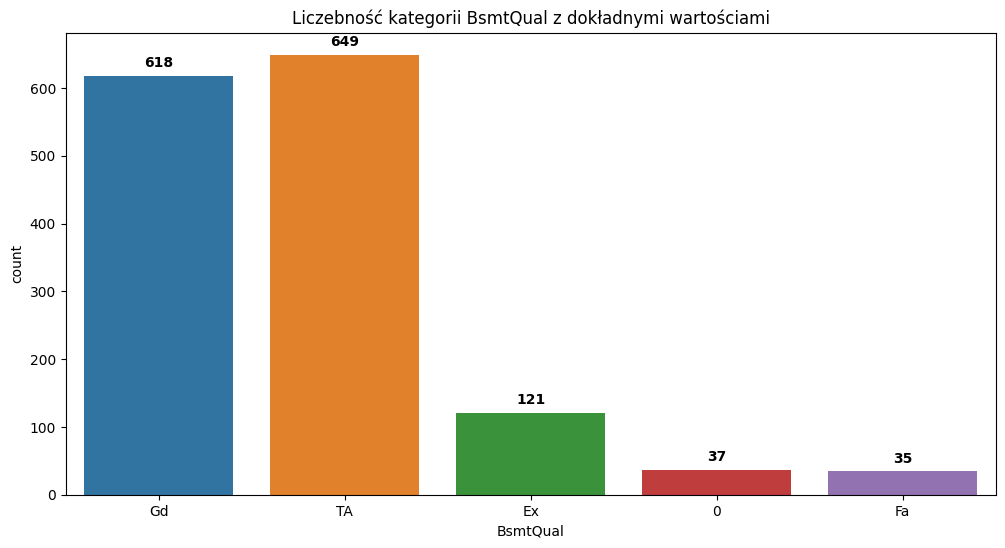

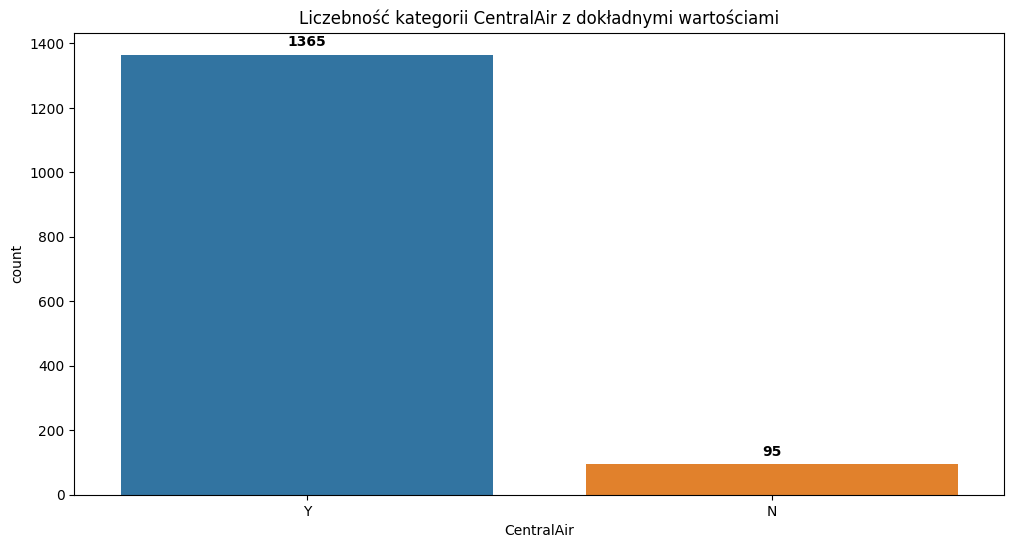

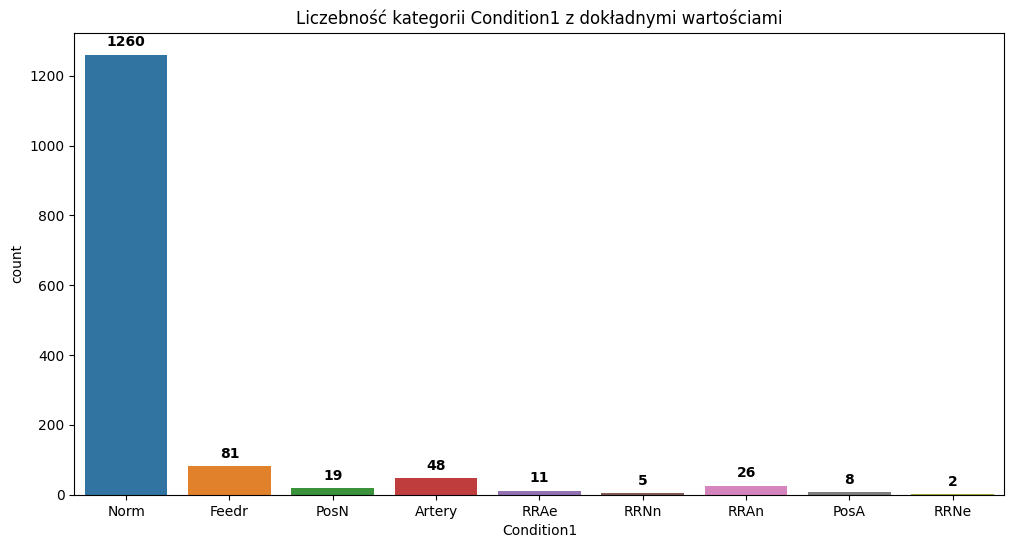

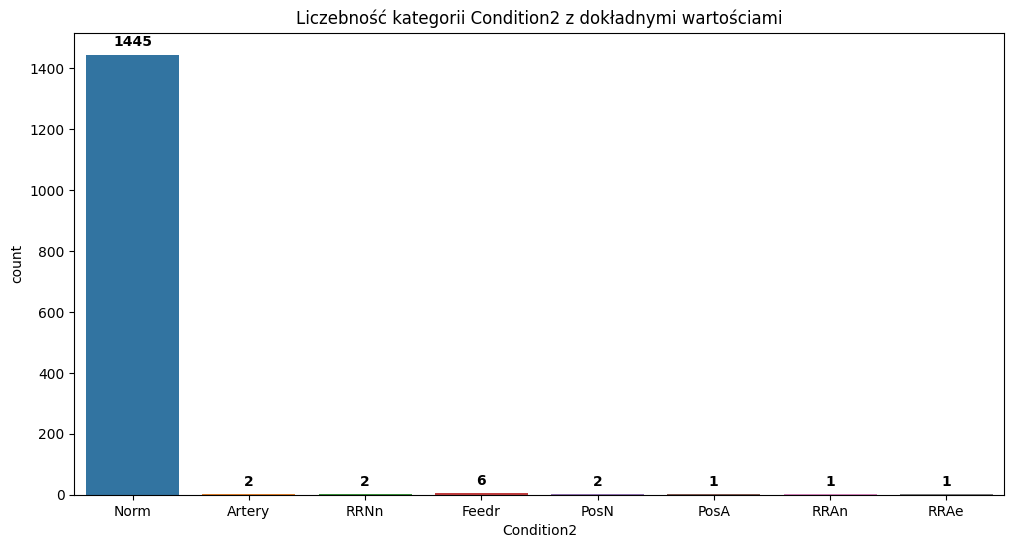

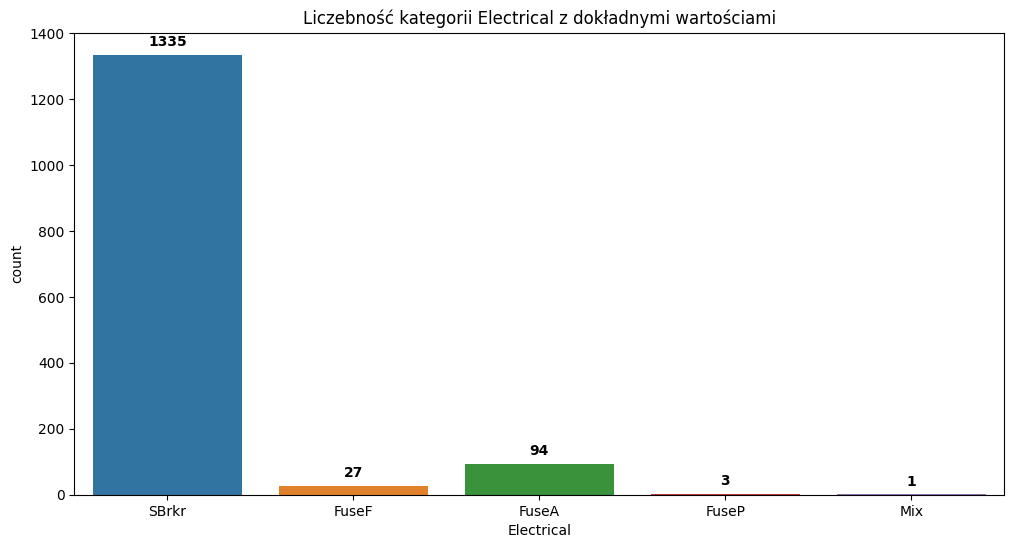

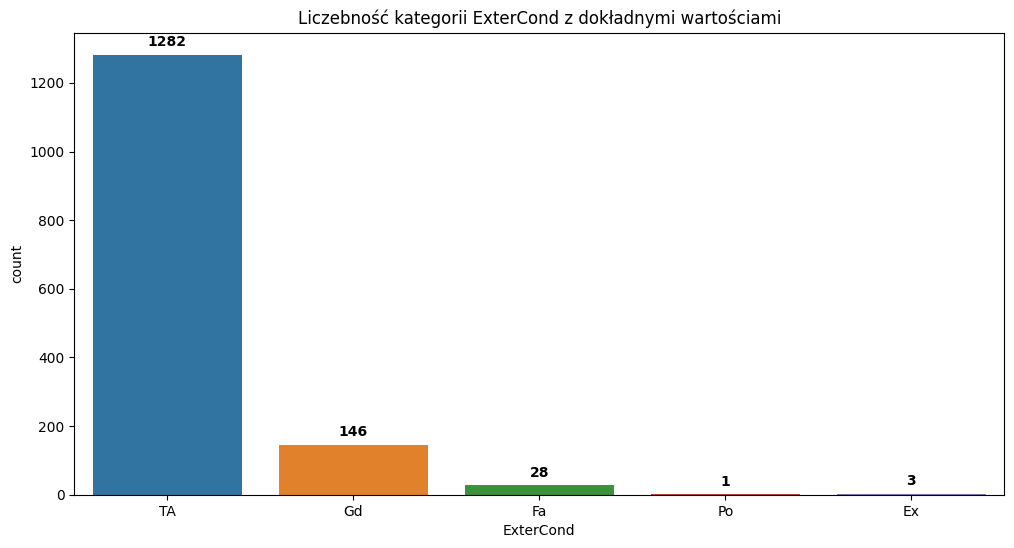

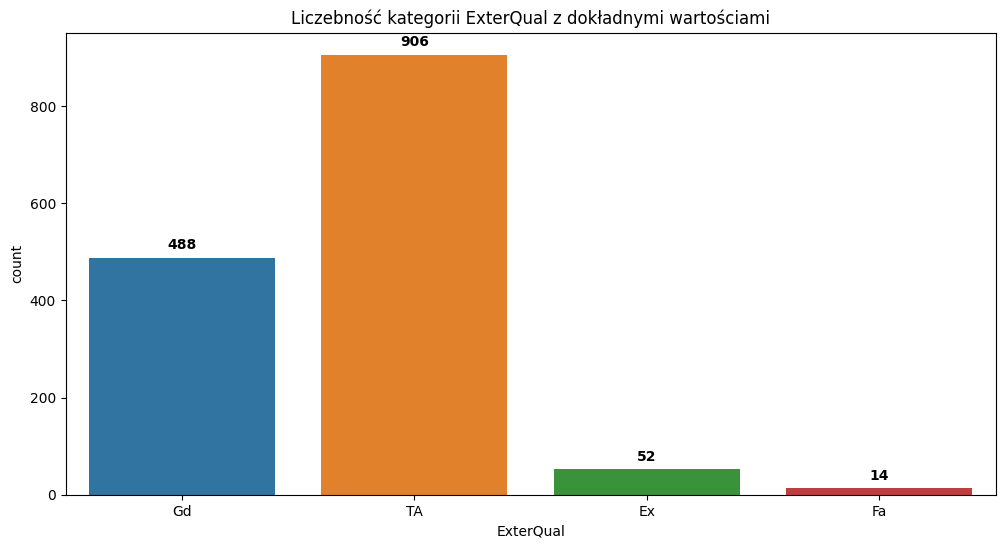

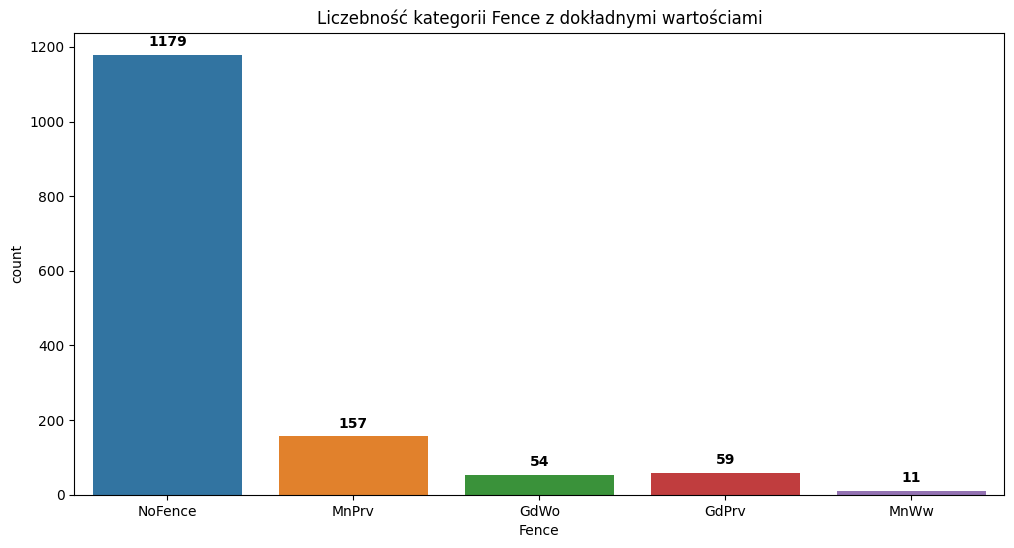

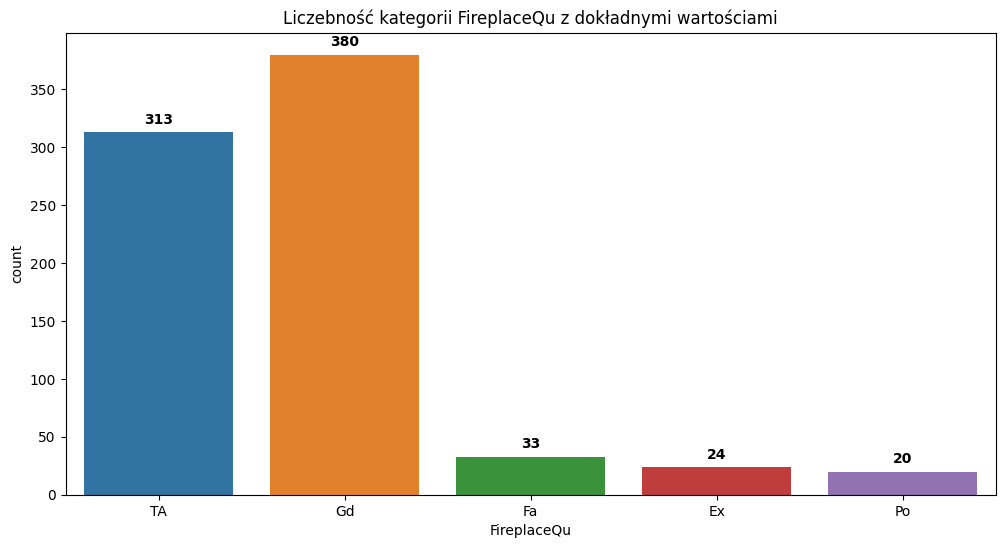

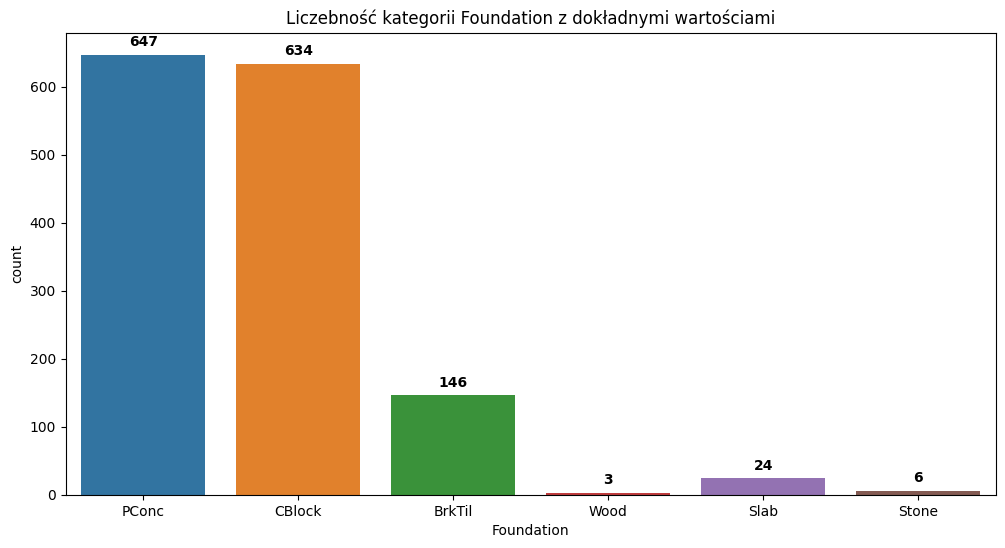

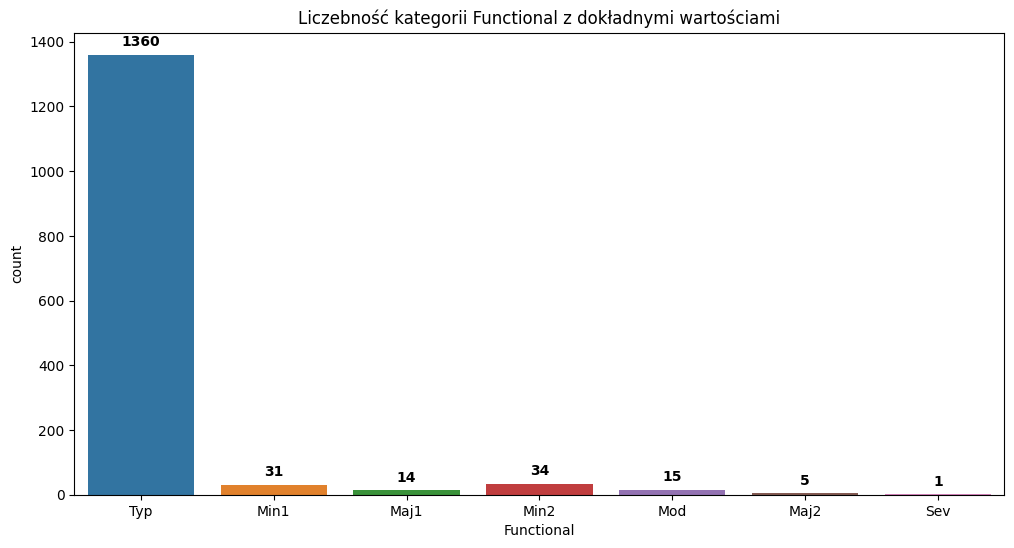

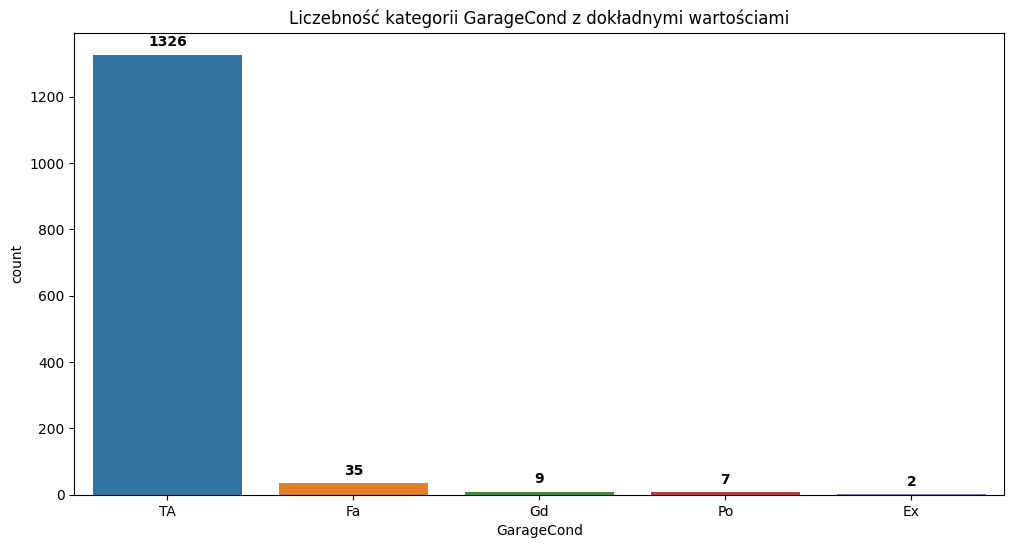

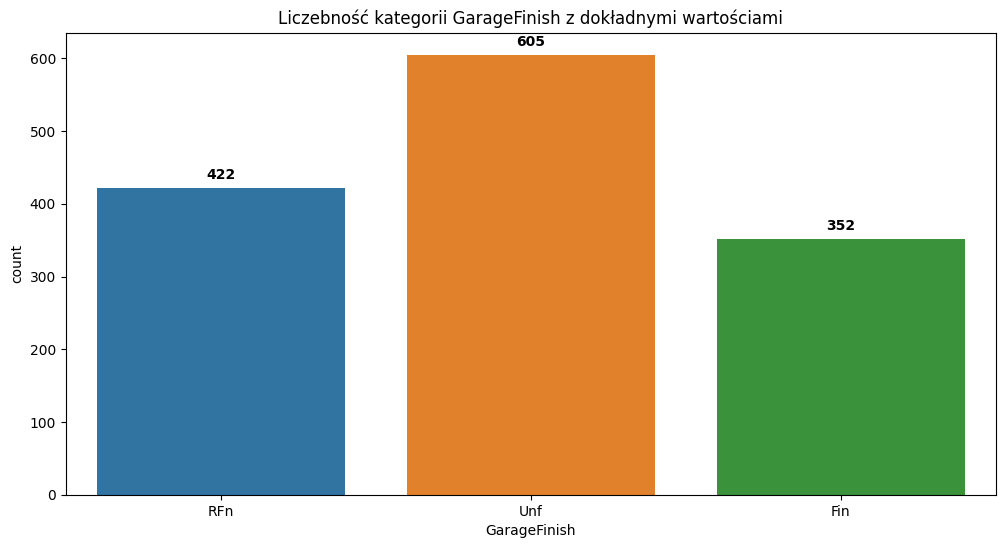

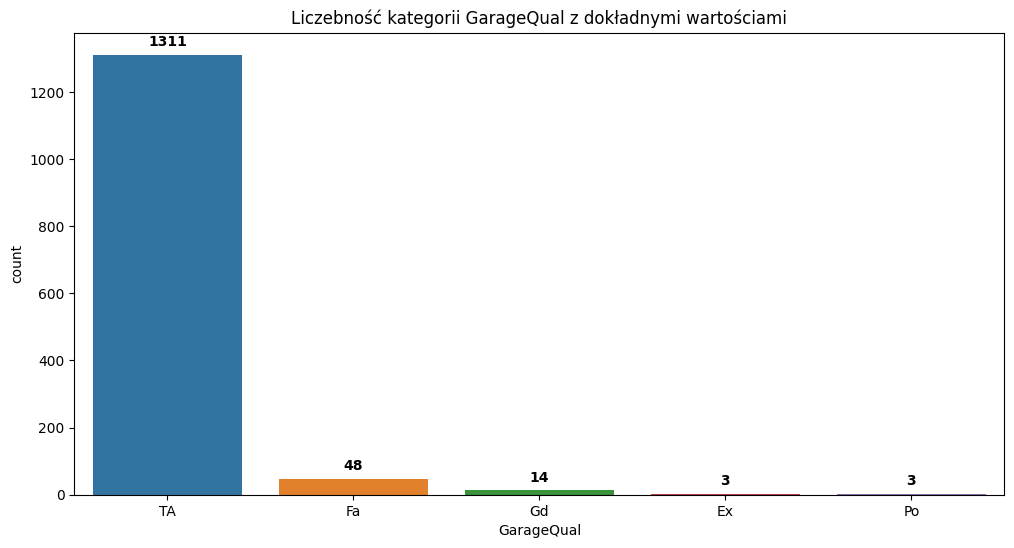

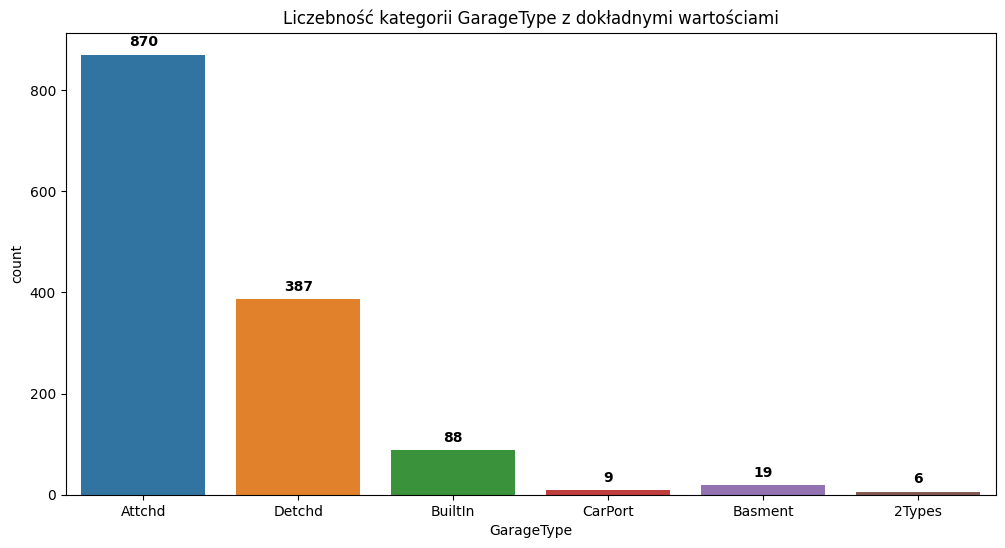

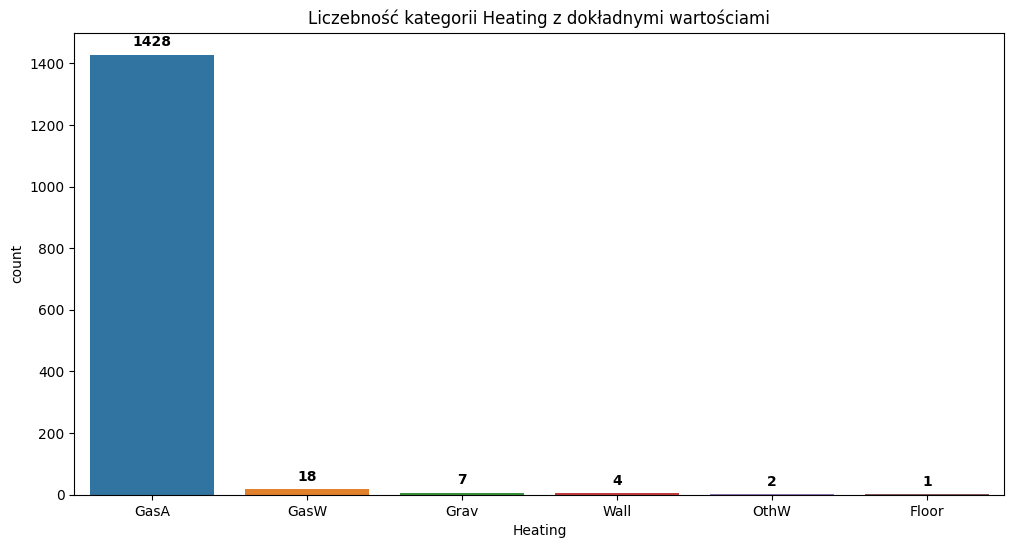

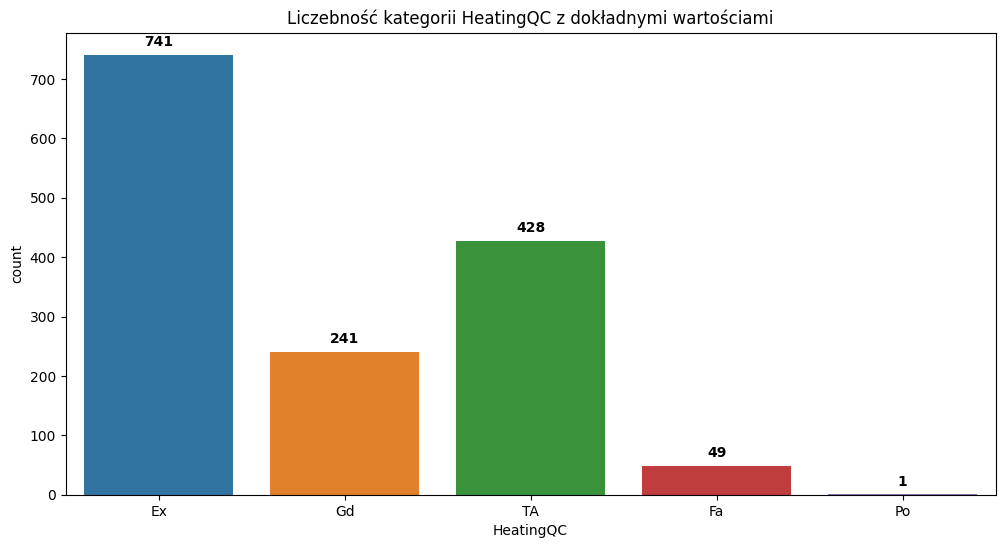

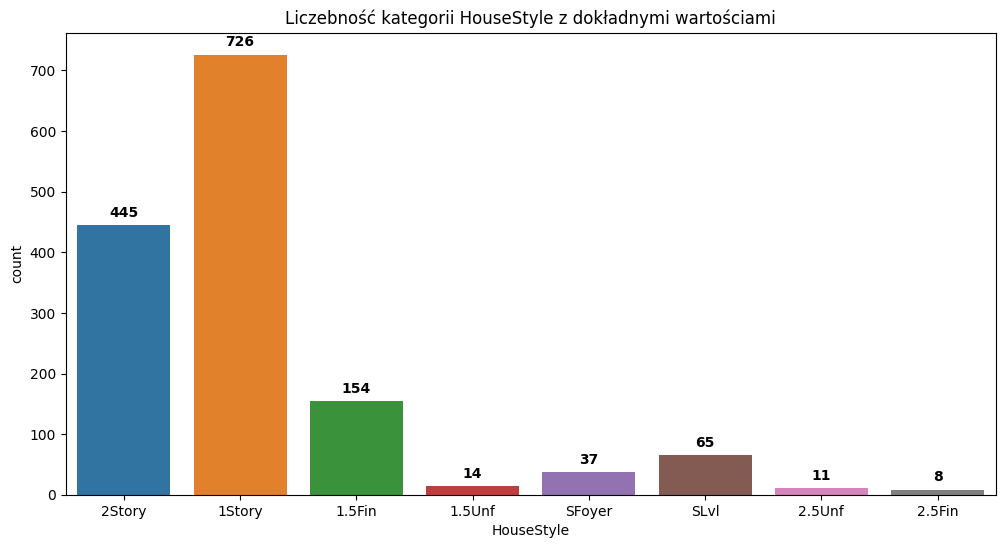

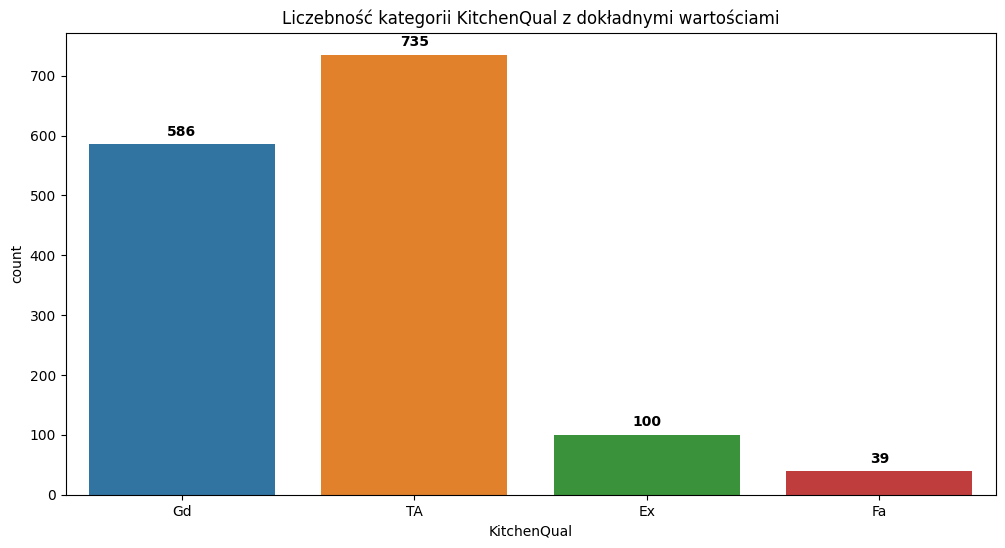

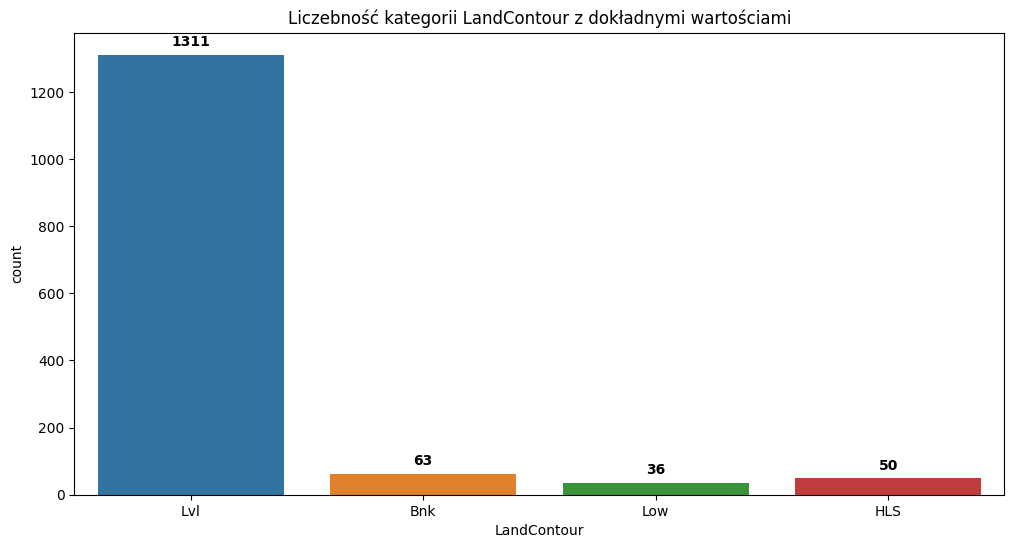

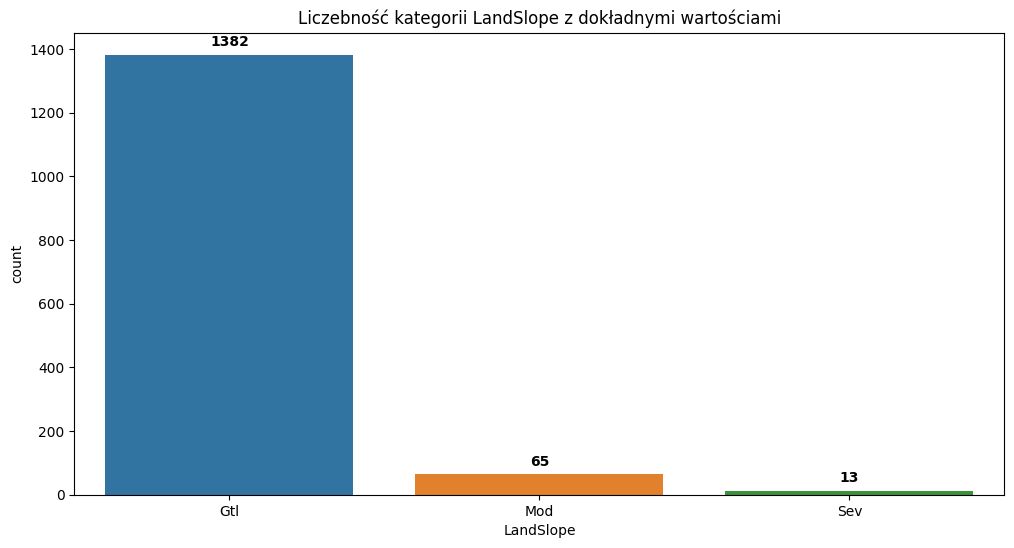

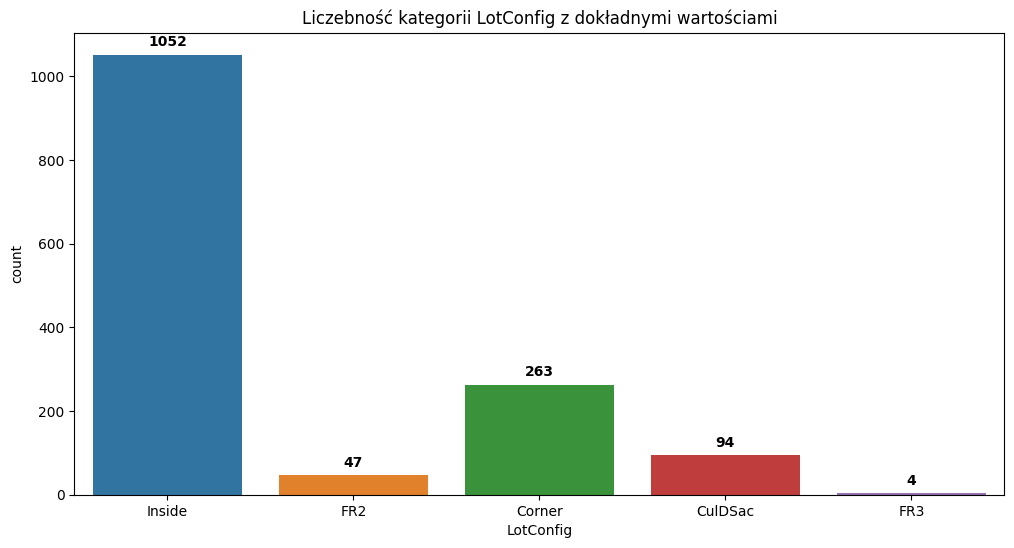

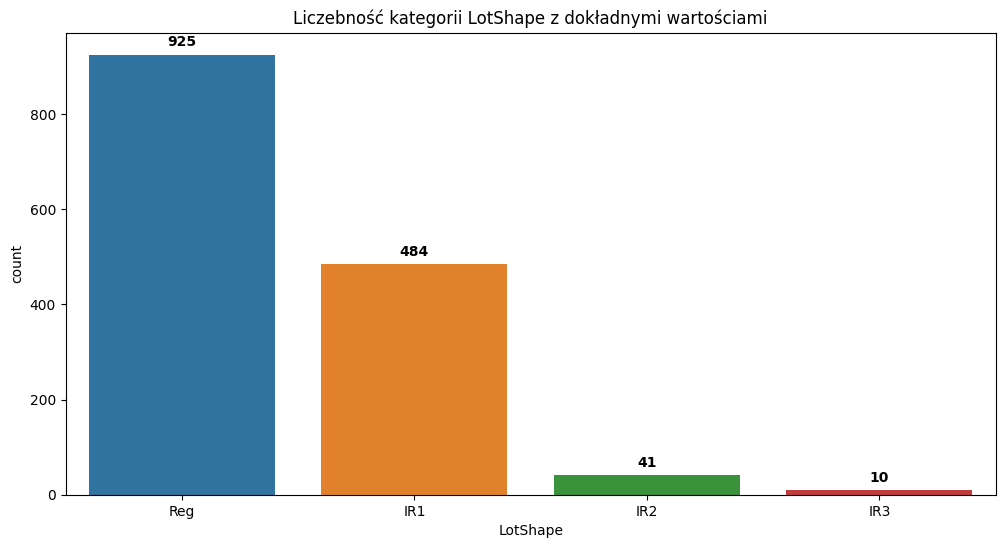

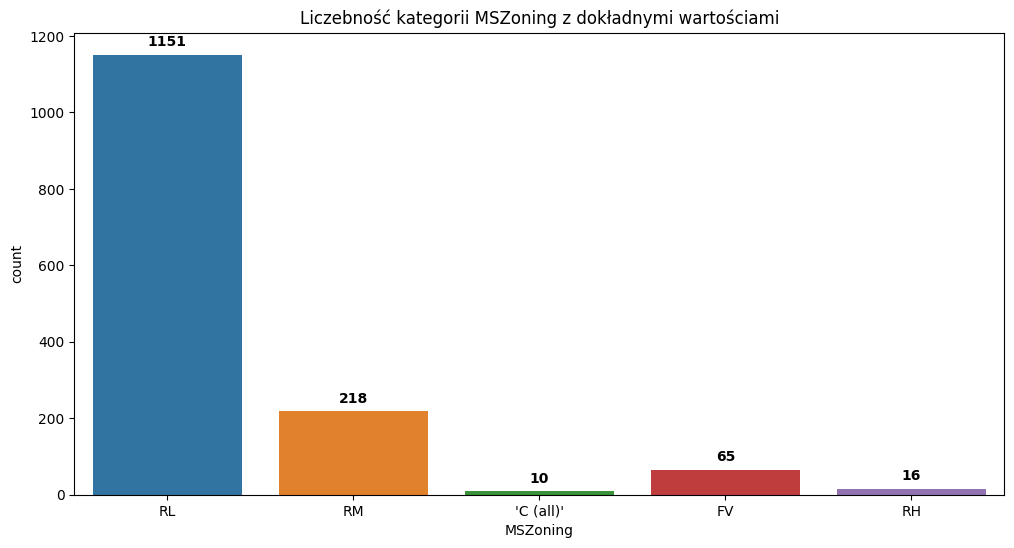

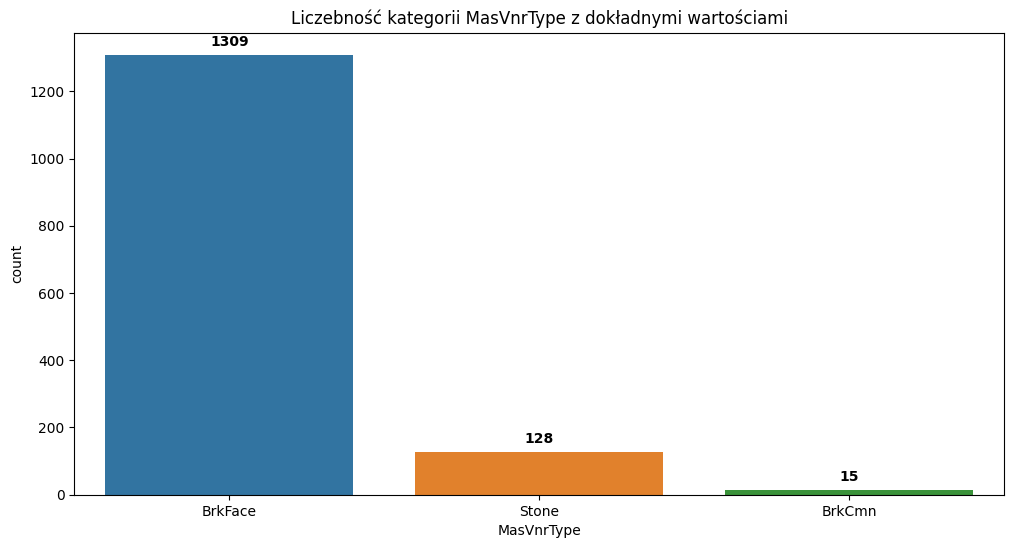

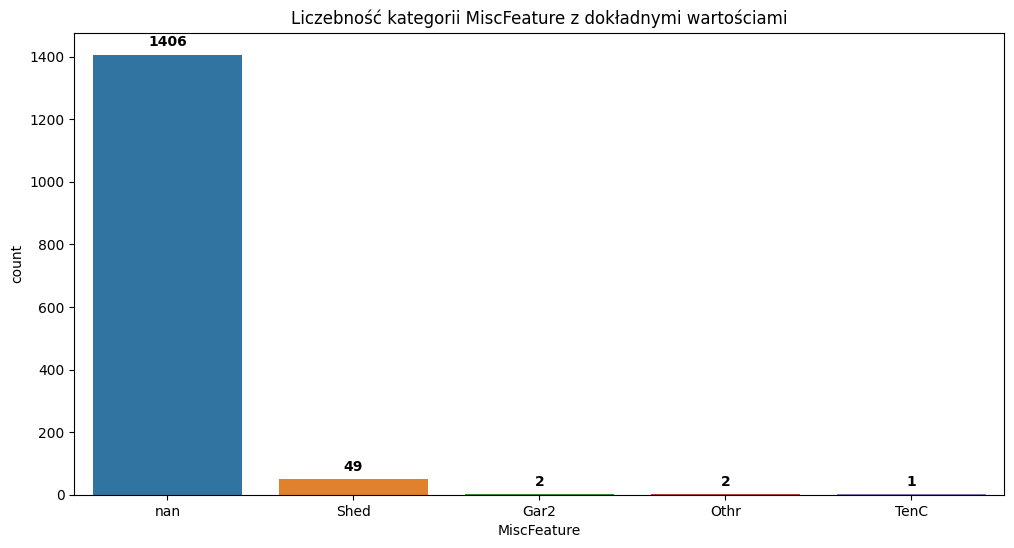

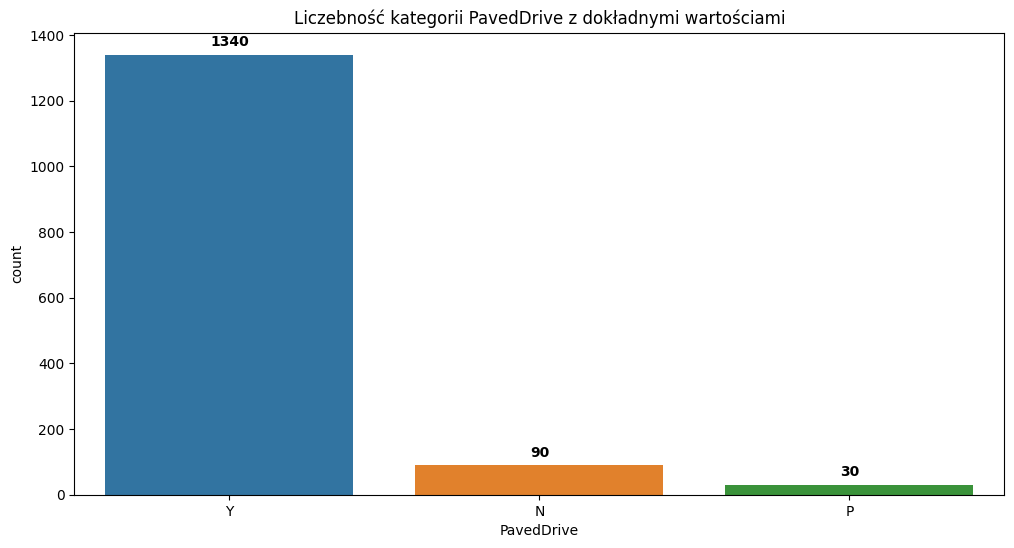

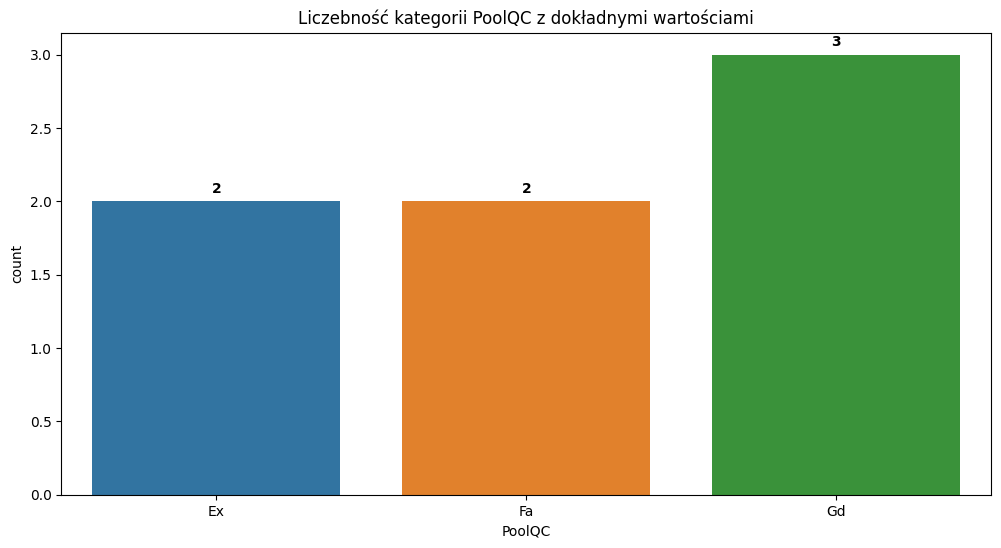

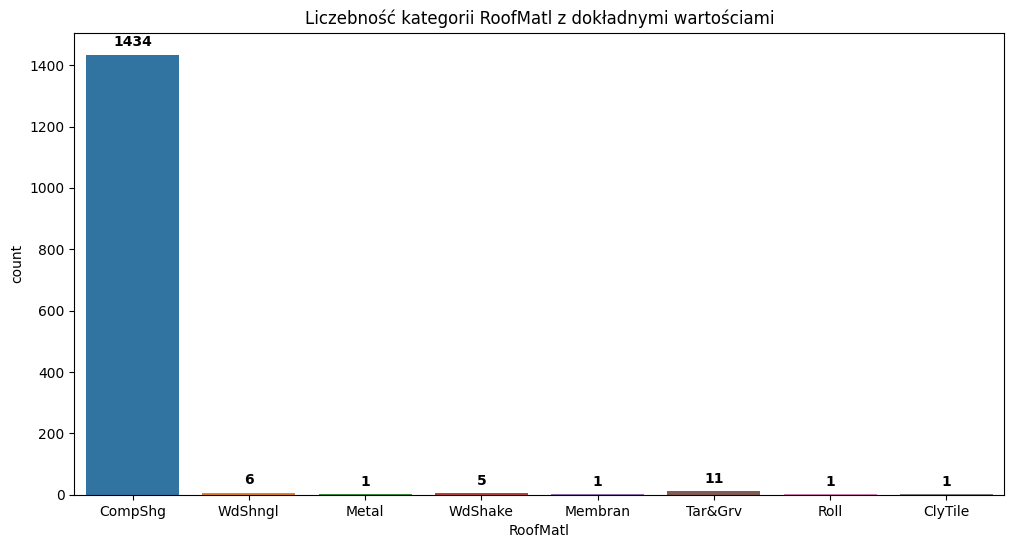

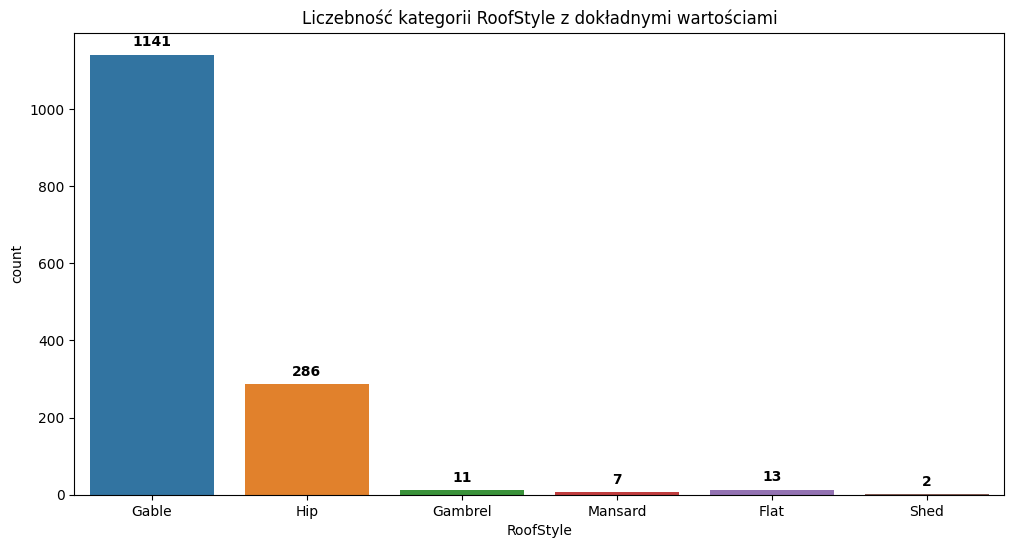

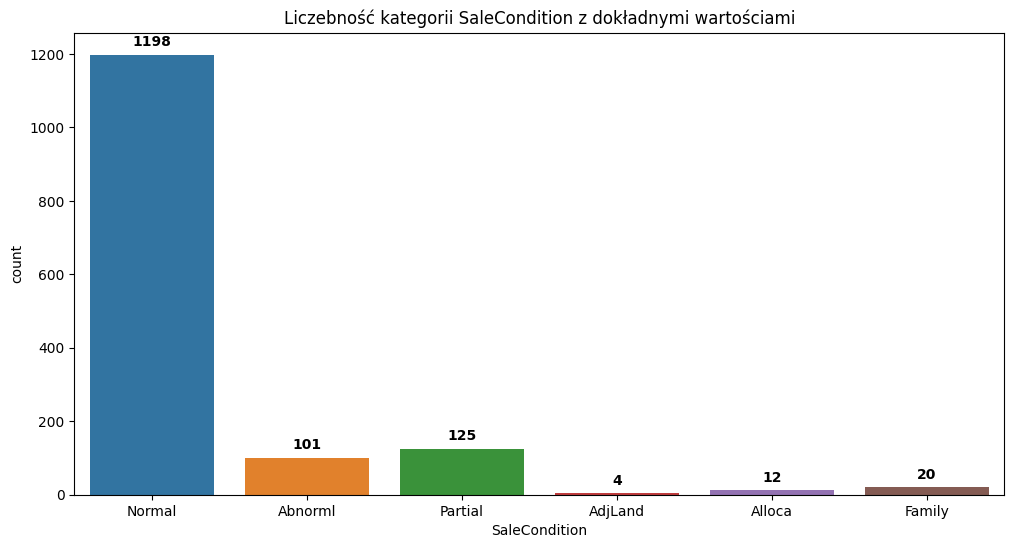

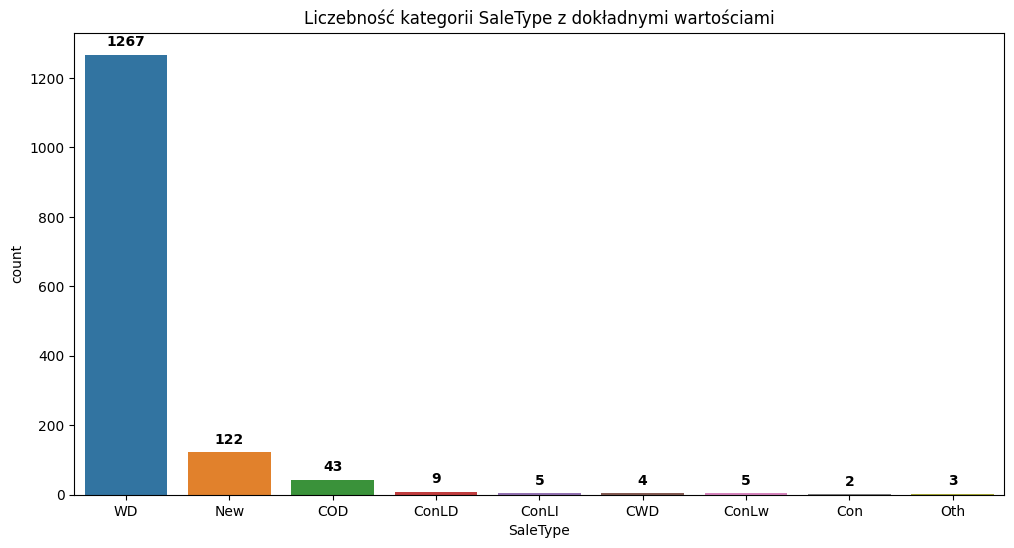

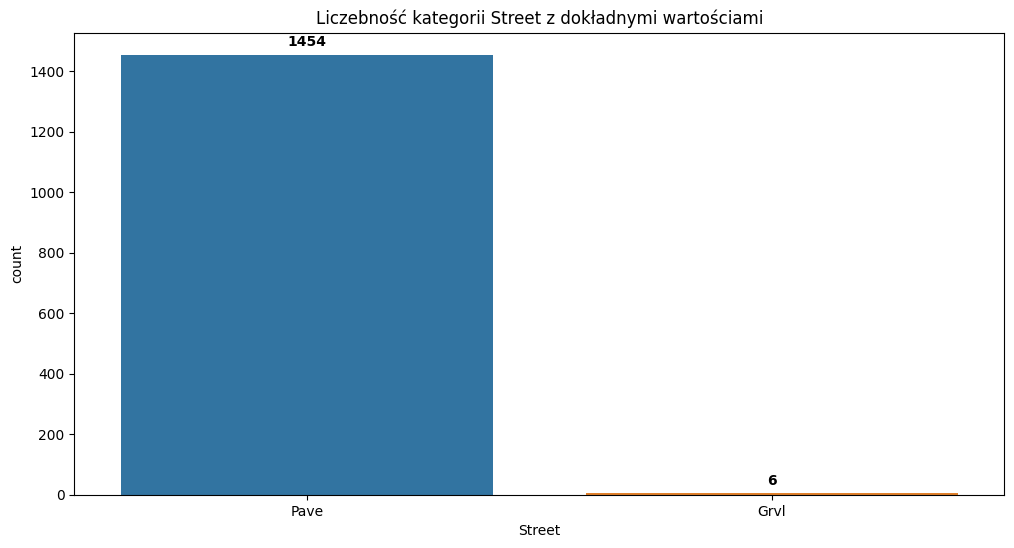

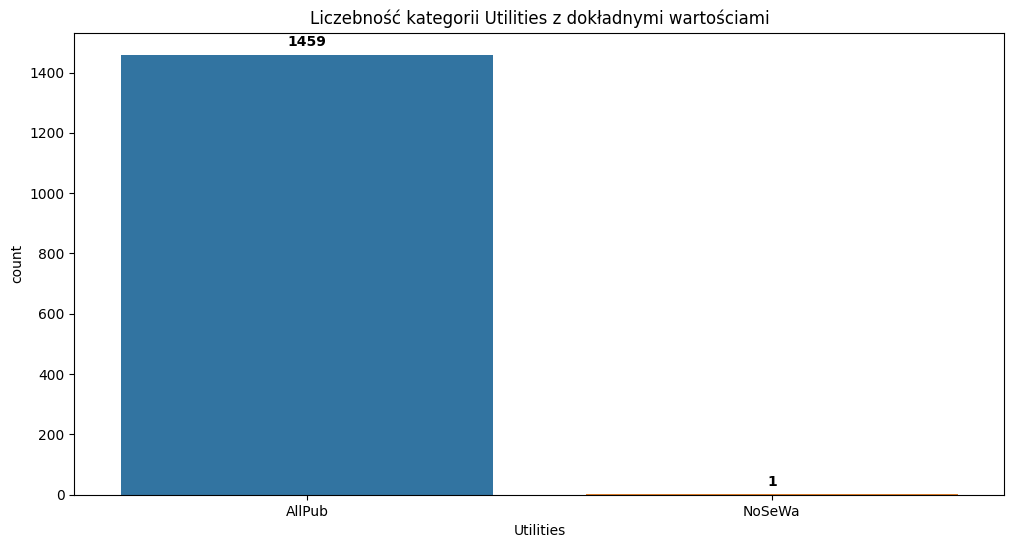

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
df_cat_s = df_cat_s.sort_index(axis=1)
for col in df_cat_s.columns:
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(data=df_cat_s, x=col)
    
    # Dodawanie liczb nad słupkami
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.0f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points',
                       fontsize=10,
                       fontweight='bold')
    
    plt.title("Liczebność kategorii " + col + " z dokładnymi wartościami")
    plt.savefig("tabela_z_matplotlib.png", bbox_inches='tight', dpi=300)
    plt.show()

In [6]:
with pd.option_context('display.max_rows', None):
    print(df['MiscFeature'])

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
5       Shed
6        NaN
7       Shed
8        NaN
9        NaN
10       NaN
11       NaN
12       NaN
13       NaN
14       NaN
15       NaN
16      Shed
17      Shed
18       NaN
19       NaN
20       NaN
21       NaN
22       NaN
23       NaN
24       NaN
25       NaN
26       NaN
27       NaN
28       NaN
29       NaN
30       NaN
31       NaN
32       NaN
33       NaN
34       NaN
35       NaN
36       NaN
37       NaN
38       NaN
39       NaN
40       NaN
41       NaN
42       NaN
43       NaN
44       NaN
45       NaN
46       NaN
47       NaN
48       NaN
49       NaN
50       NaN
51      Shed
52       NaN
53       NaN
54       NaN
55       NaN
56       NaN
57       NaN
58       NaN
59       NaN
60       NaN
61       NaN
62       NaN
63       NaN
64       NaN
65       NaN
66       NaN
67       NaN
68       NaN
69       NaN
70       NaN
71       NaN
72       NaN
73       NaN
74       NaN
75       NaN
76       NaN

In [7]:
braki = df.isna().sum()

# Wyświetlamy tylko te kolumny, gdzie liczba braków jest > 0
print(braki[braki > 0])

MasVnrType         8
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
MiscFeature     1406
dtype: int64


In [8]:
df['MiscFeature'] = df['MiscFeature'].replace('nan', 'None')

In [9]:
df['MiscFeature'] = df['MiscFeature'].astype(str)

In [10]:
df['MiscFeature']


0        nan
1        nan
2        nan
3        nan
4        nan
        ... 
1455     nan
1456     nan
1457    Shed
1458     nan
1459     nan
Name: MiscFeature, Length: 1460, dtype: object

In [11]:
df['MiscFeature'].value_counts()


MiscFeature
nan     1406
Shed      49
Gar2       2
Othr       2
TenC       1
Name: count, dtype: int64